In [2]:
import yfinance as yf
import pandas as pd
from datetime import datetime
import os

In [3]:
def get_data():

    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

    data = yf.download(
        tickers,
        period="5d",
        interval="1h"
    )

    if not os.path.exists("data"):
        os.makedirs("data")

    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")

    filename = f"data/{timestamp}.csv"

    data.to_csv(filename)

    print(f"Data saved to {filename}")

In [4]:
get_data()

[*********************100%***********************]  5 of 5 completed

Data saved to data/20260309-123439.csv


In [5]:
import matplotlib.pyplot as plt
import glob

In [6]:
def plot_data():

    files = glob.glob("data/*.csv")
    latest_file = max(files)

    data = pd.read_csv(latest_file, header=[0,1], index_col=0)

    close_data = data["Close"]

    plt.figure(figsize=(10,6))

    for ticker in close_data.columns:
        plt.plot(close_data.index, close_data[ticker], label=ticker)

    plt.title("FAANG Stock Prices (Last 5 Days)")
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")
    plt.legend()

    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    filename = f"plots/{timestamp}.png"

    plt.savefig(filename)

    plt.show()

    print(f"Plot saved to {filename}")

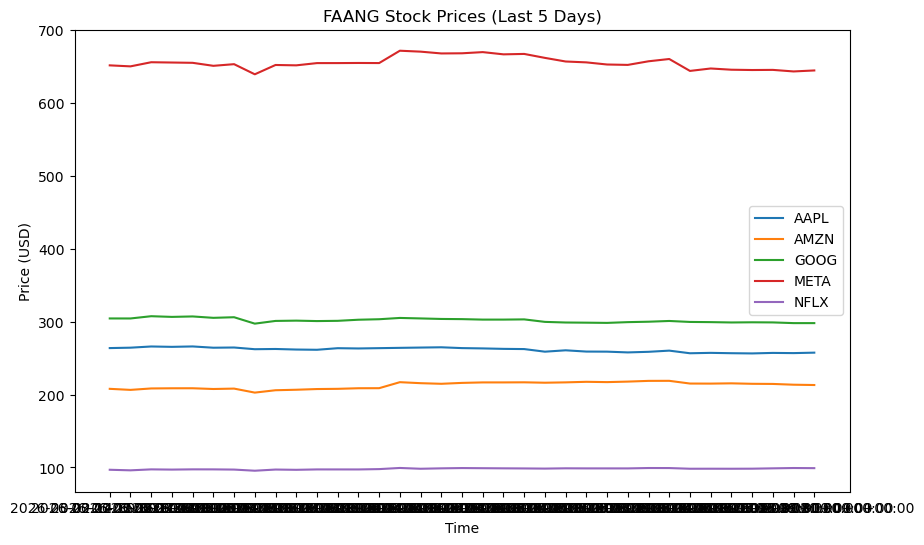

Plot saved to plots/20260309-124954.png


In [7]:
plot_data()

/var/folders/vf/d31hw_f11mj9k804v5_7zl3h0000gn/T/ipykernel_15434/2382611413.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


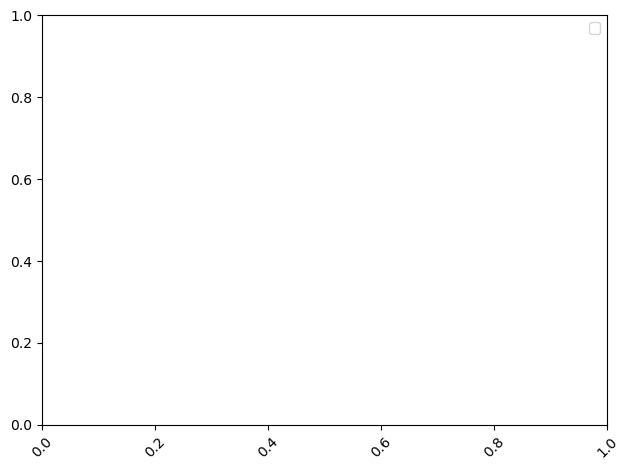

In [8]:
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
filename = f"plots/{timestamp}.png"